In [ ]:
%pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'torch'

In [ ]:
#TRANSFORM: Convert image to tensor and normalize
transform = transforms.Compose([transforms.ToTensor()                  #image -> Tensor
                                ,transforms.Normalize((0.5),(0.5))])   #normalization to range (-1,1)

#training data
train_dataset = torchvision.datasets.MNIST(
    root='.',
    train =True,
    download = True,
    transform=transform)

#test data
test_dataset = torchvision.datasets.MNIST(
    root='.',
    train=False,
    download=True,
    transform=transform
)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples:     {len(test_dataset)}')

NameError: name 'transforms' is not defined

In [ ]:
train_loaders = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = 64,      # process 64 images at a time
    shuffle = True        # shuffle training data
)


test_loaders = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = 64,    
    shuffle = False
)

Batch shape: torch.Size([64, 1, 28, 28])
Labels:      tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


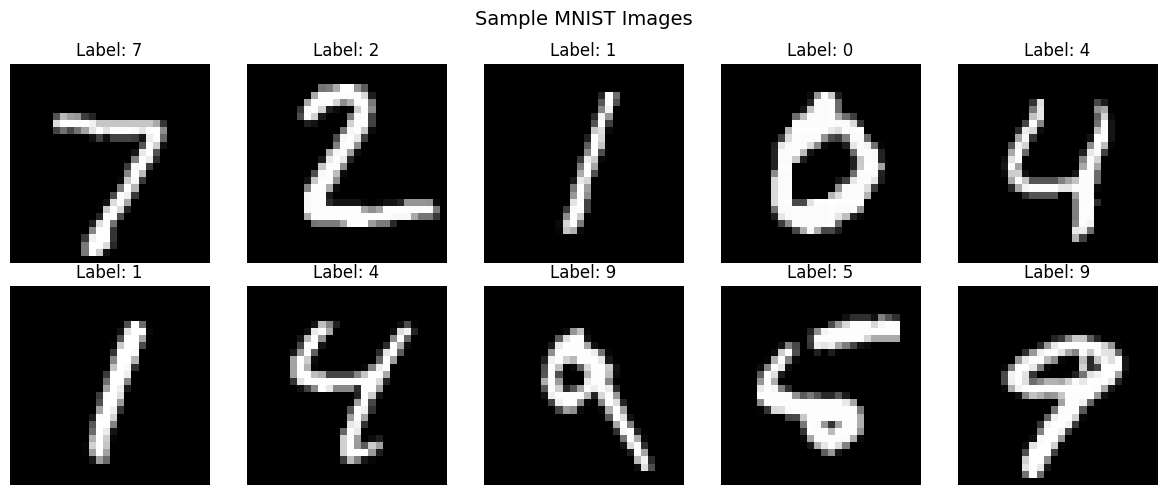

In [ ]:
#getting one batch
images,labels = next(iter(train_loaders))

print(f'Batch shape: {images.shape}')   # [64, 1, 28, 28]
print(f'Labels:      {labels[:10]}')    # first 10 labels

# plot first 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
class MNISTNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),       #28x28 = 784
            nn.Linear(784,256),  #hidden layer1
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,10)     # output layer (no softmax — CrossEntropyLoss handles it)
        )
        
    def forward(self, x):
        return self.network(x)

# create model instance
model = MNISTNetwork()
print(model)

MNISTNetwork(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
# loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)

print(f'Loss Function: {criterion}')
print(f'Optimizer:     {optimizer}')

Loss Function: CrossEntropyLoss()
Optimizer:     Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for images,labels  in train_loaders:
        #forward pass
        outputs = model(images)
        loss = criterion(outputs,labels)
        
        #backward pass
        optimizer.zero_grad() #clear old gradients
        loss.backward()       #compute gradients
        optimizer.step()      #update weights
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loaders)
    print(f'Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}')    


Epoch [1/10] Loss: 0.8640
Epoch [2/10] Loss: 0.3636
Epoch [3/10] Loss: 0.2997
Epoch [4/10] Loss: 0.2521
Epoch [5/10] Loss: 0.2151
Epoch [6/10] Loss: 0.1914
Epoch [7/10] Loss: 0.1745
Epoch [8/10] Loss: 0.1606
Epoch [9/10] Loss: 0.1423
Epoch [10/10] Loss: 0.1214


In [ ]:
model.eval()   # set to evaluation mode
correct = 0
total = 0

with torch.no_grad():   # no gradient calculation needed
    for images, labels in test_loaders:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)   # get highest probability class
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 95.06%


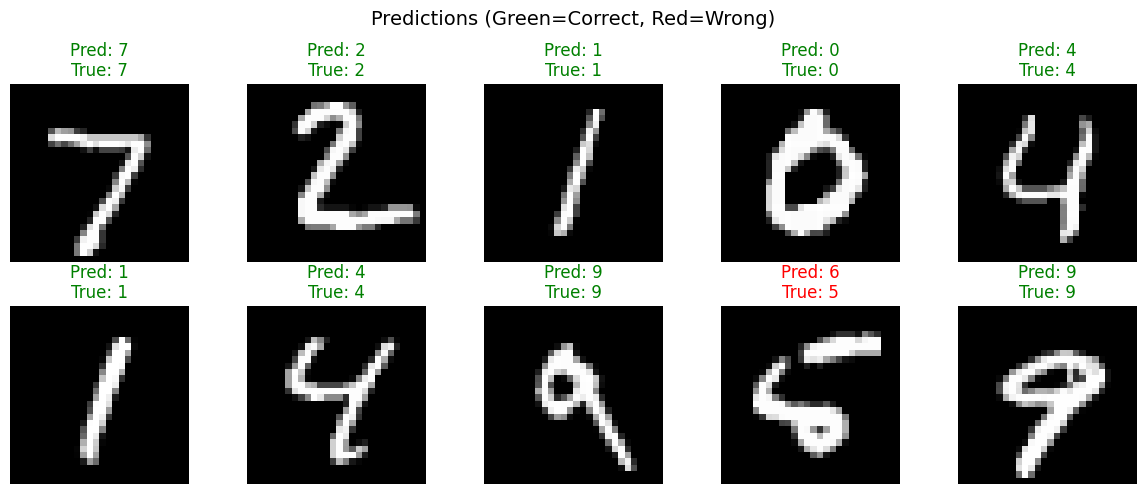

In [ ]:
model.eval()
images, labels = next(iter(test_loaders))

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# plot 10 predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f'Pred: {predicted[i]}\nTrue: {labels[i]}', color=color)
    ax.axis('off')

plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()